# 1. Data loading

### 1.1 Importing modules

In [319]:
# import all modules
import pandas as pd
import geopandas as gpd
import requests
import matplotlib.pyplot as plt
!pip install contextily
import contextily as cx

In [320]:
area_url='https://firms.modaps.eosdis.nasa.gov/api/area/csv/38064bff4711161d2878baf2b432ef5f/VIIRS_NOAA20_NRT/world/3'

response=requests.get(area_url)
# print(response.text) #here I saw that its already plain text and not json to parse, no .json() to unpack required

#Check
if response.status_code==200:
      print("Request worked")
else:
      print("Request did not work")

# Create dataframe
df_area = pd.read_csv(area_url)
df_area

Request worked


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,55.96853,160.59933,367.00,0.59,0.53,2026-05-14,56,N20,VIIRS,h,2.0NRT,310.43,50.48,D
1,64.64521,24.42407,329.33,0.39,0.36,2026-05-14,109,N20,VIIRS,n,2.0NRT,281.26,3.20,N
2,64.64832,24.42700,295.40,0.39,0.36,2026-05-14,109,N20,VIIRS,n,2.0NRT,279.35,0.68,N
3,64.65274,24.42233,308.33,0.39,0.36,2026-05-14,109,N20,VIIRS,n,2.0NRT,279.48,0.68,N
4,52.53268,39.63256,313.27,0.76,0.77,2026-05-14,111,N20,VIIRS,n,2.0NRT,260.49,2.35,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82108,-37.35778,175.11497,302.88,0.42,0.45,2026-05-16,1253,N20,VIIRS,n,2.0NRT,278.47,0.76,N
82109,-37.20269,174.72131,299.91,0.44,0.46,2026-05-16,1253,N20,VIIRS,n,2.0NRT,277.72,1.20,N
82110,-37.20086,174.72374,306.62,0.44,0.46,2026-05-16,1253,N20,VIIRS,n,2.0NRT,278.33,1.23,N
82111,-45.98522,169.81755,305.49,0.47,0.47,2026-05-16,1255,N20,VIIRS,n,2.0NRT,271.28,0.66,N


# 2. Data cleaning

In [355]:
wildfire_gdf=gpd.GeoDataFrame(df_area, geometry=gpd.points_from_xy(df_area["longitude"], df_area["latitude"]), crs=(4326))
print(wildfire_gdf.head(3))
print(wildfire_gdf.describe())
print(wildfire_gdf.crs)

   latitude  longitude  bright_ti4  scan  track    acq_date  acq_time  \
0  55.96853  160.59933      367.00  0.59   0.53  2026-05-14        56   
1  64.64521   24.42407      329.33  0.39   0.36  2026-05-14       109   
2  64.64832   24.42700      295.40  0.39   0.36  2026-05-14       109   

  satellite instrument confidence version  bright_ti5    frp daynight  \
0       N20      VIIRS          h  2.0NRT      310.43  50.48        D   
1       N20      VIIRS          n  2.0NRT      281.26   3.20        N   
2       N20      VIIRS          n  2.0NRT      279.35   0.68        N   

                     geometry  
0  POINT (160.59933 55.96853)  
1   POINT (24.42407 64.64521)  
2     POINT (24.427 64.64832)  
           latitude     longitude    bright_ti4          scan         track  \
count  82113.000000  82113.000000  82113.000000  82113.000000  82113.000000   
mean       8.738904     28.789147    333.777269      0.458253      0.473843   
std       23.265931     73.308410     15.647862  

In [370]:
#Cut off extremes, differentiate between frp_raw for analysis, and frp_vis for visualization

wildfire_gdf = wildfire_gdf[wildfire_gdf["frp"] > 30].copy()

wildfire_gdf["frp_raw"] = wildfire_gdf["frp"]

upper = wildfire_gdf["frp"].quantile(0.99)

wildfire_gdf["frp_vis"] = wildfire_gdf["frp"].clip(upper=upper)

# 3. Spatial analysis

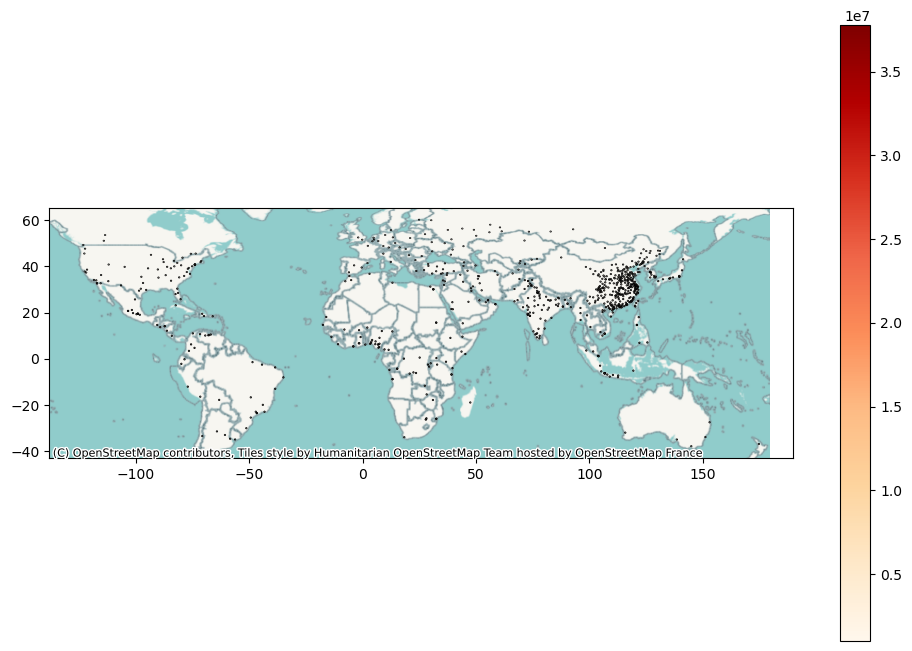

In [371]:
# Spatial analysis part: Load in world-cities (worldcities_csv), select only where population large, buffer around them, look if intersection with filter
# spatial inner join, make table with cities affected. make f"string for each city affected f"Warning: The city of {city} with population {population}
# is at risk of wildfire. Prepare for evacuation. Starting Date of fire. Confidence/uncertainty."

worldcities_df=pd.read_csv(r"..\data\raw\worldcities.csv")

# Make geodataframe, lat, lng
worldcities_gdf=gpd.GeoDataFrame(worldcities_df, geometry=gpd.points_from_xy(x=worldcities_df["lng"], y=worldcities_df["lat"]),  crs="4326")

# Select only cities with population larger than 1 Million
large_worldcities_gdf=worldcities_gdf[worldcities_gdf["population"] > 1000000]

# Change projection to mercator, because WG84 is in degrees, not in meters. Then create buffer of 15km
large_worldcities_gdf=large_worldcities_gdf.to_crs(epsg=3857)
large_worldcities_gdf['geometry'] = large_worldcities_gdf.geometry.buffer(20000) #in meters

# zurücktransformieren
large_worldcities_gdf = large_worldcities_gdf.to_crs(epsg=4326)

fig, ax=plt.subplots(figsize=(12, 8))

# plot
large_worldcities_gdf.plot(ax=ax,
    column="population",
    cmap="OrRd",
    legend=True,
    edgecolor="black"
)


cx.add_basemap(
    ax,
    crs="EPSG:4326"
)


In [398]:
#spatial inner join, city buffer and wildfires

large_worldcities_gdf=large_worldcities_gdf.to_crs(epsg=4326)
wildfire_gdf=wildfire_gdf.to_crs(epsg=4326)

cities_fire_gdf=gpd.sjoin(wildfire_gdf, large_worldcities_gdf, how="inner", predicate="intersects")

cities_fire_gdf

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,...,city_ascii,lat,lng,country,iso2,iso3,admin_name,capital,population,id
17834,-6.30809,20.75662,347.66,0.55,0.43,2026-05-14,1225,N20,VIIRS,n,...,Tshikapa,-6.4167,20.8000,Congo (Kinshasa),CD,COD,Kasaï,admin,1006387.0,1180581239
38897,36.47139,114.52898,339.26,0.42,0.38,2026-05-15,533,N20,VIIRS,n,...,Handan,36.6010,114.4870,China,CN,CHN,Hebei,minor,2708015.0,1156957080
42538,28.46924,77.35800,331.25,0.62,0.71,2026-05-15,854,N20,VIIRS,n,...,Faridabad,28.4211,77.3078,India,IN,IND,Haryāna,NaN,1404653.0,1356013205
42539,28.47097,77.35813,348.71,0.62,0.71,2026-05-15,854,N20,VIIRS,n,...,Faridabad,28.4211,77.3078,India,IN,IND,Haryāna,NaN,1404653.0,1356013205
42541,28.47585,77.35761,344.52,0.62,0.71,2026-05-15,854,N20,VIIRS,n,...,Faridabad,28.4211,77.3078,India,IN,IND,Haryāna,NaN,1404653.0,1356013205
42542,28.47618,77.36407,367.00,0.62,0.71,2026-05-15,854,N20,VIIRS,h,...,Faridabad,28.4211,77.3078,India,IN,IND,Haryāna,NaN,1404653.0,1356013205
42543,28.47758,77.35777,367.00,0.62,0.71,2026-05-15,854,N20,VIIRS,h,...,Faridabad,28.4211,77.3078,India,IN,IND,Haryāna,NaN,1404653.0,1356013205


In [ ]:
# Early warning system dashboard
# 3. View the fused attribute table
for row in cities_fire_gdf.itertuples():
    print(f"Alert warning: The city of {row.city_ascii}" f" with a population of {row.population:,} is threatened by wildfire by a proximate wildfire of less than 20 kilometers distance. Prepare for immediate evacuation.")

Alert warning: The city of Tshikapa with a population of 1,006,387.0 is threatened by wildfire by a proximate wildfire of less than 20 kilometers distance. Prepare for immediate evacuation.
Alert warning: The city of Handan with a population of 2,708,015.0 is threatened by wildfire by a proximate wildfire of less than 20 kilometers distance. Prepare for immediate evacuation.
Alert warning: The city of Faridabad with a population of 1,404,653.0 is threatened by wildfire by a proximate wildfire of less than 20 kilometers distance. Prepare for immediate evacuation.
Alert warning: The city of Faridabad with a population of 1,404,653.0 is threatened by wildfire by a proximate wildfire of less than 20 kilometers distance. Prepare for immediate evacuation.
Alert warning: The city of Faridabad with a population of 1,404,653.0 is threatened by wildfire by a proximate wildfire of less than 20 kilometers distance. Prepare for immediate evacuation.
Alert warning: The city of Faridabad with a popul

In [ ]:
# Table join, in which countries most wildfires

<function matplotlib.pyplot.show(close=None, block=None)>

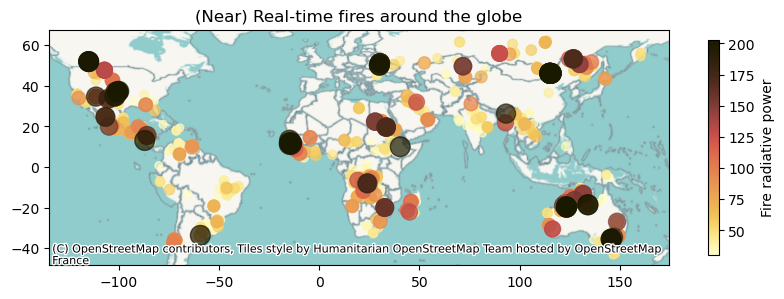

In [414]:
import cmcrameri.cm as cmc
#cmc lipari or OrRd or lajolla

wildfire_gdf_sorted=wildfire_gdf.sort_values("frp_vis")

fig, ax= plt.subplots(figsize=(10,4))

legend_options= legend_options = { "label": "Fire radiative power", "orientation": "vertical", "shrink": 0.7}
wildfire_gdf_sorted.plot(ax=ax, column="frp_vis", cmap="cmc.lajolla_r", markersize="frp_vis", alpha=0.7, legend=True, legend_kwds=legend_options)
cx.add_basemap(ax=ax, crs=4326)
plt.title("(Near) Real-time fires around the globe")
plt.show

In [158]:
#Introduce uncertainty with transparency
wildfire_gdf["confidence"].unique()

import numpy as np

wildfire_gdf["alpha"] = np.select(
    [
        wildfire_gdf["confidence"] == "h",
        wildfire_gdf["confidence"] == "n",
        wildfire_gdf["confidence"] == "l",
    ],
    [
        1.0,
        0.7,
        0.4
    ],
    default=0.5
)

In [ ]:
# Next step: Do proper map, with normalizing, making classification, handling missing values and so on using this code and practicals VL8
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import cmcrameri.cm as cmc
# import numpy as np

# # 1. Setup
# fig, ax = plt.subplots(figsize=(12, 10))

# # 4. Legend options
# legend_options = {
#     "label": "Ratio: Women per 100 Men",
#     "orientation": "vertical",
#     "shrink": 0.7
# }

# # 6. Missing data options
# missing_styling = {
#     "color": "#EEEEEE",
#     "label": "No Data"
# }

# # 2, 3, 5. Plot the choropleth
# nuts.plot(
#     ax=ax,
#     column="women_per100men",
#     cmap=cmc.vik, 
#     vmin=vmin,
#     vmax=vmax,
#     legend=True,
#     legend_kwds=legend_options,
#     missing_kwds=missing_styling,
#     edgecolor="black",
#     linewidth=0.1
# )

# # 7. Formatting
# ax.set_title("Gender Ratio Across European Regions", fontsize=16)
# ax.axis("off")
ax.grid(True)

# plt.show()

# 4. Visualization

In [289]:
# Best interactive map until now

import numpy as np
import folium
import matplotlib.cm as cm
import matplotlib.colors as colors

# SORT (big fires last → on top)
wildfire_filtered = wildfire_filtered.sort_values("frp_vis", ascending=True)

# Color scale based on VISUAL values
vmin = wildfire_filtered["frp_vis"].min()
vmax = wildfire_filtered["frp_vis"].max()

norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.get_cmap("YlOrRd")

# Map (dark background)
m = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles="CartoDB dark_matter",
    #control_scale=True
)


for _, row in wildfire_filtered.iterrows():

    frp = row["frp_vis"]

    # SIZE (direct scaling, no sqrt/log)
    radius = max(frp / 10, 2)

    # COLOR (based on same variable)
    color = colors.to_hex(cmap(norm(frp)))

    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.75,
        popup=f"FRP [MW]: {row['frp']:.1f},  Date: {row['acq_date']}"
    ).add_to(m)

m.save("wildfire2.html")

C:\Users\Javier Feller\AppData\Local\Temp\ipykernel_39568\3001905583.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlOrRd")


In [291]:
# Prepare Interactive map with recentness of events

# convert aqc_date and aqc_time to acq_datetime as datetime object
wildfire_gdf['acq_datetime'] = pd.to_datetime(wildfire_gdf['acq_date'] + ' ' + wildfire_gdf['acq_time'].astype(str).str.zfill(4), format='%Y-%m-%d %H%M')

# find maximum time from our dataset since we are pretending current date time is July 12 2023, 19:50(7:50pm) GMT.
# if the data were recent, we would set 
dt_max = pd.Timestamp.now();

# create our subsets for 4 color classes

# less than or equal to 1 hour; gdf1 <= 1hour
wildfire_gdf_12h = wildfire_gdf[wildfire_gdf['acq_datetime'] >= (dt_max - pd.Timedelta(hours=12))]

# greater than 1 hour but less than or equal to 24 hours; gdf2 > 1 hour and gdf2 <= 12 hours
wildfire_gdf_24h = wildfire_gdf[(wildfire_gdf['acq_datetime'] >= (dt_max - pd.Timedelta(hours=24))) & (wildfire_gdf['acq_datetime'] < (dt_max - pd.Timedelta(hours=12)))]

# greater than 1 hour but less than or equal to 24 hours; gdf2 > 1 hour and gdf2 <= 12 hours
wildfire_gdf_48h = wildfire_gdf[(wildfire_gdf['acq_datetime'] >= (dt_max - pd.Timedelta(hours=48))) & (wildfire_gdf['acq_datetime'] < (dt_max - pd.Timedelta(hours=24)))]

# greater than 24 hours; gdf4 > 12 hours
wildfire_gdf_more48h = wildfire_gdf[wildfire_gdf['acq_datetime'] < (dt_max - pd.Timedelta(hours=48))]

# now let's make sure the sizes are correct. They should all add up to 14045
# print ('Sizes %i, %i, %i, %i from total of %i' % (wildfire_gdf_1h.count()[0],wildfire_gdf_12h.count()[0],wildfire_gdf_24h.count()[0],wildfire_gdf_more24h.count()[0], gdf.count()[0]))

C:\Users\Javier Feller\AppData\Local\Temp\ipykernel_39568\1618935137.py:36: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  wildfire_12h.plot(


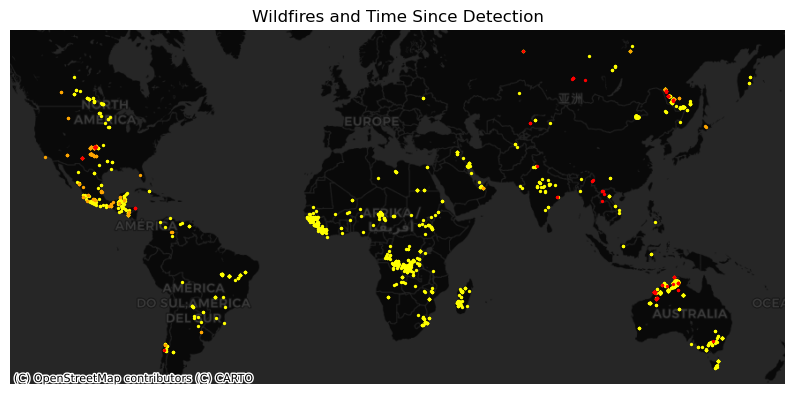

In [292]:
import matplotlib.pyplot as plt
import contextily as cx

# Reproject to Web Mercator
wildfire_more48h = wildfire_gdf_more24h.to_crs(epsg=3857)
wildfire_48h = wildfire_gdf_24h.to_crs(epsg=3857)
wildfire_24h = wildfire_gdf_12h.to_crs(epsg=3857)
wildfire_12h = wildfire_gdf_5h.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))

# -------------------------
# Fire layers (old → new)
# -------------------------
wildfire_more48h.plot(
    ax=ax,
    color="yellow",
    markersize=2,
    alpha=1
)

wildfire_48h.plot(
    ax=ax,
    color="orange",
    markersize=2,
    alpha=1
)

wildfire_24h.plot(
    ax=ax,
    color="red",
    markersize=2,
    alpha=1
)

wildfire_12h.plot(
    ax=ax,
    color="darkred",
    markersize=2,
    alpha=1
)

# -------------------------
# Basemap
# -------------------------
cx.add_basemap(
    ax=ax,
    source=cx.providers.CartoDB.DarkMatter
)

# -------------------------
# Styling
# -------------------------
ax.set_title("Wildfires and Time Since Detection")
ax.set_axis_off()

plt.show()

In [293]:
import folium

# --------------------------------------------
# MAP
# --------------------------------------------
m = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles="CartoDB dark_matter",
    prefer_canvas=True
)

# ============================================
# FUNCTION
# ============================================

def add_fire_layer(gdf, color, opacity):

    # sort small -> large
    gdf = gdf.sort_values("frp_vis", ascending=True)

    for _, row in gdf.iterrows():

        # FRP = size
        radius = max(row["frp_vis"] / 10, 2)

        popup_text = (
            f"<b>FRP:</b> {row['frp']:.1f} MW<br>"
            f"<b>Date:</b> {row['acq_datetime']}<br>"
            f"<b>Confidence:</b> {row['confidence']}"
        )

        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=radius,
            color=color,
            weight=0,
            fill=True,
            fill_color=color,
            fill_opacity=opacity,
            popup=folium.Popup(popup_text, max_width=250)
        ).add_to(m)

# ============================================
# TIME CLASSES
# ============================================

# # older fires
add_fire_layer(
    wildfire_gdf_more48h,
    color="yellow",
    opacity=1
)

# medium recent fires
add_fire_layer(
    wildfire_gdf_48h,
    color="orange",
    opacity=1
)

# new fires
add_fire_layer(
    wildfire_gdf_24h,
    color="red",
    opacity=1
)

# newest fires
add_fire_layer(
    wildfire_gdf_12h,
    color="darkred",
    opacity=1
)

# ============================================
# SAVE
# ============================================



# ============================================
# LEGEND
# ============================================

legend_html = """
<div style="
    position: fixed;
    bottom: 40px;
    left: 40px;
    width: 180px;
    height: 220px;
    background-color: black;
    border:2px solid grey;
    z-index:9999;
    font-size:14px;
    color:white;
    padding: 10px;
    opacity: 0.85;
">

<b>Wildfire Detection Time</b><br><br>

<i style="background:yellow;
width:12px;
height:12px;
float:left;
margin-right:8px;
opacity:1;"></i>
Older than 48 hours<br><br>

<i style="background:orange;
width:12px;
height:12px;
float:left;
margin-right:8px;
opacity:1;"></i>
24–48 hours <br><br>

<i style="background:red;
width:12px;
height:12px;
float:left;
margin-right:8px;
opacity:1;"></i>
12–24 hours <br><br>

<i style="background:darkred;
width:12px;
height:12px;
float:left;
margin-right:8px;
opacity:1;"></i>
Last 12 hours

</div>
"""

m.get_root().html.add_child(folium.Element(legend_html))

m.save("wildfire_bestuntil_know.html")